# Traffic-signal-control experiment

This notebook compares simple baselines, MAPPO, and reward-sharing MAPPO on a network.

In [1]:
import os
import subprocess
import sys
import sysconfig
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path("/content/marl-tsc")

    if not ROOT.exists():
        subprocess.run([
            "git", "clone", "--branch", "zak-pre-experiment",
            "--single-branch", "https://github.com/abergh18/marl-tsc.git",
            str(ROOT)
        ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "eclipse-sumo"
    ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "-r", str(ROOT / "requirements.txt"),
    ], check=True)

    import sumo
    os.environ["SUMO_HOME"] = sumo.SUMO_HOME
    sys.path.insert(0, os.path.join(sumo.SUMO_HOME, "tools"))

    from google.colab import userdata

    #Get access token
    token = userdata.get('GH_TOKEN')

else:
    # Run VS Code from somewhere inside the marl-tsc repository.
    ROOT = next(
        folder
        for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / "src" / "marl_tsc").exists()
    )

# Make /src/marl_tsc importable.
sys.path.insert(0, str(ROOT / "src"))

# Relative project paths now work consistently.
os.chdir(ROOT)

print(f"Running in {'Colab' if IN_COLAB else 'VS Code'} from {ROOT}")

Running in Colab from /content/marl-tsc


In [2]:
if not IN_COLAB:
  %reload_ext autoreload
  %autoreload 2

import matplotlib.pyplot as plt

from marl_tsc.baselines import fixed_time_actions, random_actions
from marl_tsc.mappo import train_mappo
from marl_tsc.network_types import CityNetwork, GridNetwork
from marl_tsc.simulation_generator import SimulationGenerator
from marl_tsc.training import (
    evaluate_policies,
    export_policy_replay,
    evaluation_results_table,
    plot_training_histories,
)

## 1. Configure and generate the simulation

In [3]:
import urllib.request

if IN_COLAB:
    # Create a custom opener to disguise script as a web browser
    opener = urllib.request.build_opener()
    opener.addheaders = [
        ("User-Agent", "Mozilla/5.0 (Windows NT 10.0; Win64; x64)")
    ]

    # Apply this rule globally for this notebook
    urllib.request.install_opener(opener)

In [4]:
SEED = 42
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)
TOTAL_TIMESTEPS = 60_000
EVALUATION_EPISODES = 3

# The same environment settings are used for training, evaluation, and replay.
ENV_KWARGS = {
    "green_phase_count": None,
    "min_green_seconds": 10,
    "seconds_per_action": SECONDS_PER_ACTION,
    "switch_penalty": 0.1,
    "collect_global_metrics": True,
    "global_metric_interval": 10,
}

OUTPUT_DIR = ROOT / "outputs"
SIMULATION_DIR = OUTPUT_DIR / "simulation"
#network = CityNetwork(city_name="Lancaster, UK", radius=500)
network = GridNetwork(4)
generator = SimulationGenerator(
    output_dir=SIMULATION_DIR,
    network=network,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=3,
    seed=SEED,
)

paths = generator.generate_all()
traffic_light_ids = list(paths.traffic_light_ids)
print(f"Generated SUMO config: {paths.config_file}")
print(f"Traffic-light agent count: {len(traffic_light_ids)}")

Generated SUMO config: /content/marl-tsc/outputs/simulation/config.sumocfg
Traffic-light agent count: 4


## 2. Train MAPPO policies

The reward-sharing policy has an extra sharing action during training. Both policies are evaluated using the same traffic metrics.

In [5]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=False,
)

 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -300.09 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -319.29 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -314.31 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -302.38 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -312.38 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -295.65 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -301.56 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -295.90 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -314.84 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -296.17 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -284.00 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -275.43 | Total Steps: 7200
 Retrying in 1 seconds
[MAP

In [6]:
reward_sharing_model, reward_sharing_history, reward_sharing_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
    use_peer_reward=True,
)

 Retrying in 1 seconds
 Retrying in 1 seconds

Discovered Network Neighbours (Live TraCI):
  B1 -> ['C1', 'B2', 'C2']
  B2 -> ['B1', 'C1', 'C2']
  C1 -> ['B1', 'B2', 'C2']
  C2 -> ['B1', 'B2', 'C1']

[MAPPO] Episode 1 | Return: -283.51 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -333.10 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -282.41 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -310.30 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -316.94 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -300.97 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -301.97 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -289.23 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -302.53 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -270.91 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Ep

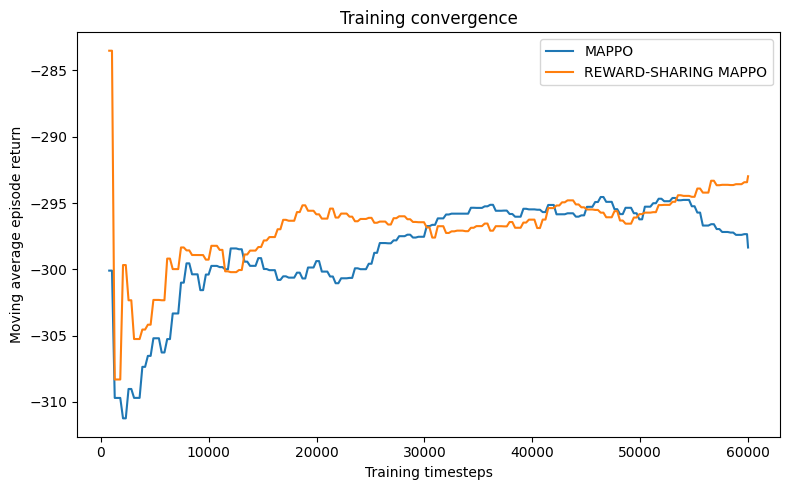

In [7]:
fig, ax = plot_training_histories({
    "MAPPO": mappo_history,
    "Reward-sharing MAPPO": reward_sharing_history,
})
plt.show()

In [ ]:
'''
import pandas as pd
import matplotlib.pyplot as plt

df_mappo_history = pd.DataFrame(mappo_history)
df_mappo_history['mean_training_reward'].plot()
plt.xlabel("Timestep")
plt.ylabel("Mean Training Reward")
plt.title("MAPPO Mean Training Reward Over Timesteps")
plt.show()
'''

In [ ]:
'''
df_rs_history = pd.DataFrame(reward_sharing_history)
df_rs_history['mean_training_reward'].plot()
plt.xlabel("Timestep")
plt.ylabel("Mean Training Reward")
plt.title("Reward-sharing MAPPO Mean Training Reward Over Timesteps")
plt.show()
'''

## 3. Export a SUMO replay

In [12]:
replay_config = export_policy_replay(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=reward_sharing_model,
    output_dir=OUTPUT_DIR / "replays" / "reward_sharing_mappo",
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)
print(f"Open this file in the SUMO GUI: {replay_config}")

 Retrying in 1 seconds
 Retrying in 1 seconds
Open this file in the SUMO GUI: /content/marl-tsc/outputs/replays/reward_sharing_mappo/replay.sumocfg


## 4. Compare all policies

Every policy uses the same evaluation episodes, seeds, and environment settings.

In [13]:
policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "MAPPO": mappo_model,
    "Reward-sharing MAPPO": reward_sharing_model,
}

policy_results = evaluate_policies(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policies=policies,
    episodes=EVALUATION_EPISODES,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)

display(evaluation_results_table(policy_results))

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1202.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1310.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1335.43
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1028.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1026.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1022.07
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -629.46
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -584.01
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -599.34
Evaluating Reward-s

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1283.075000,0.504635,8.333333,20.895747,244.666667,1708.693571,966.000000,713.666667
1,Fixed-Time,-1025.693750,0.410573,5.000000,15.345032,89.000000,1093.169552,969.333333,396.000000
2,MAPPO,-604.266667,0.223507,4.666667,9.263445,206.666667,604.786750,976.666667,676.000000
3,Reward-sharing MAPPO,-503.695833,0.179444,4.000000,5.788575,155.333333,451.155580,980.000000,728.000000


## 5. Seeded Experiments 4x4

|Seed: 0 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -282.70 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -289.72 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -288.90 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -293.23 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -341.34 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -281.55 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -299.87 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -286.86 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -303.06 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -292.62 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -315.28 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -278.12 | Total Steps: 7200
 R

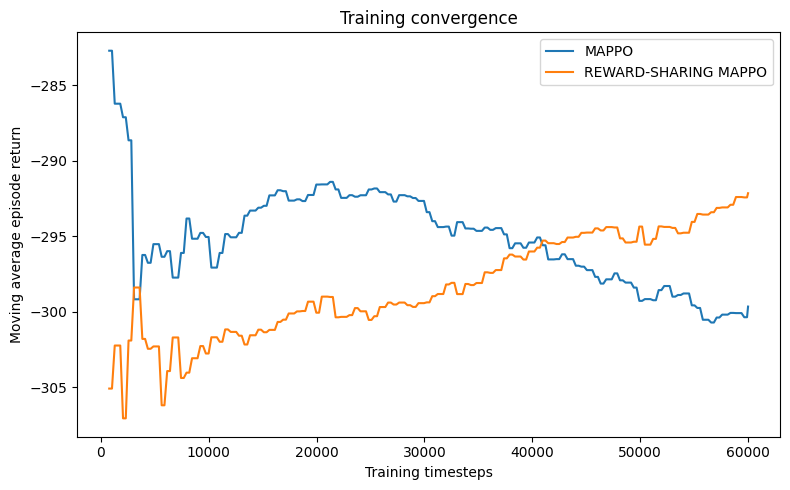

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1202.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1310.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1335.43
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1028.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1026.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1022.07
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -748.73
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -752.93
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -760.34
Evaluating Reward-s

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1283.075000,0.504635,8.333333,20.895747,244.666667,1708.693571,966.000000,713.666667
1,Fixed-Time,-1025.693750,0.410573,5.000000,15.345032,89.000000,1093.169552,969.333333,396.000000
2,MAPPO,-753.995833,0.289601,5.000000,13.363742,245.666667,852.799205,969.333333,586.000000
3,Reward-sharing MAPPO,-604.139583,0.222014,6.666667,9.868392,242.000000,632.676508,976.000000,710.666667


|Seed: 1 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -298.71 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -284.49 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -298.77 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -321.12 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -286.00 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -297.63 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -297.50 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -297.42 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -310.75 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -300.97 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -285.12 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -310.86 | Total Steps: 7200
 R

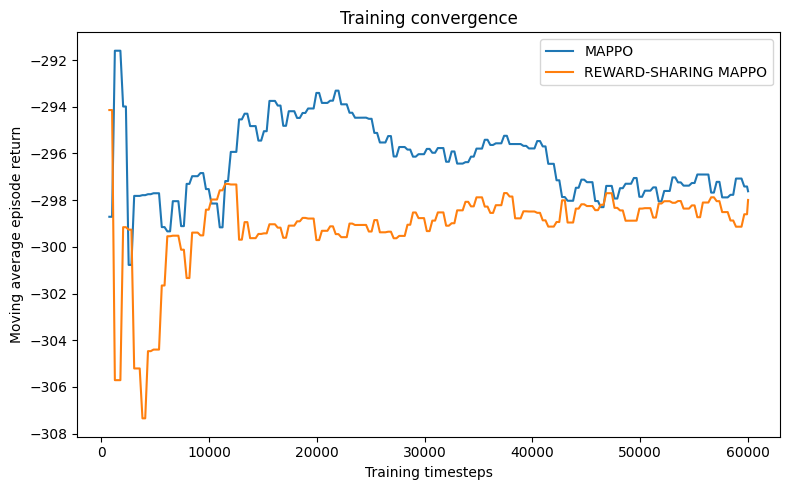

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1202.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1310.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1335.43
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1028.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1026.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1022.07
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -731.75
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -720.28
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -717.40
Evaluating Reward-s

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1283.075000,0.504635,8.333333,20.895747,244.666667,1708.693571,966.000000,713.666667
1,Fixed-Time,-1025.693750,0.410573,5.000000,15.345032,89.000000,1093.169552,969.333333,396.000000
2,MAPPO,-723.143750,0.276372,4.666667,12.340476,277.666667,804.096529,977.666667,596.333333
3,Reward-sharing MAPPO,-719.789583,0.271198,5.333333,14.655777,280.000000,857.375948,976.333333,686.333333


|Seed: 2 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -288.43 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -290.54 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -292.62 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -320.38 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -300.62 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -283.57 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -280.95 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -279.45 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -285.91 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -262.80 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -290.62 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -304.65 | Total Steps: 7200
 R

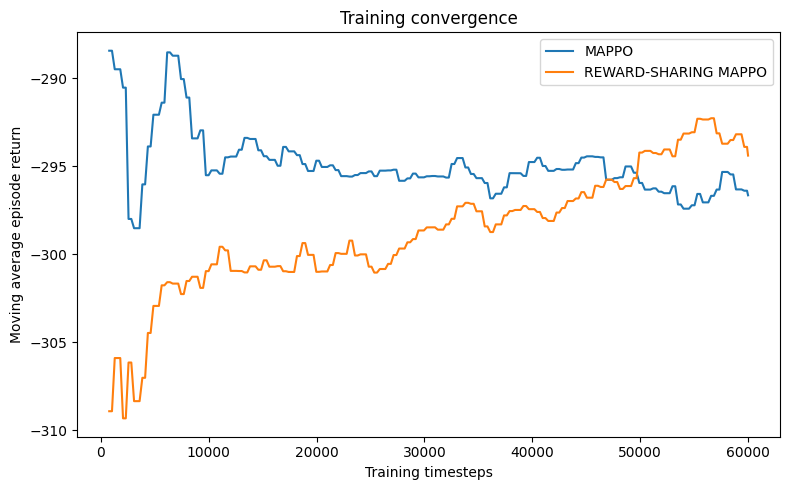

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1202.91
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1310.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1335.43
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1028.07
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1026.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1022.07
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -992.52
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1020.53
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -971.09
Evaluating Reward-

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait,Mean time loss,Mean arrivals,Mean switches
0,Random,-1283.075000,0.504635,8.333333,20.895747,244.666667,1708.693571,966.000000,713.666667
1,Fixed-Time,-1025.693750,0.410573,5.000000,15.345032,89.000000,1093.169552,969.333333,396.000000
2,MAPPO,-994.710417,0.391528,6.000000,20.689594,297.666667,1302.991457,969.333333,545.333333
3,Reward-sharing MAPPO,-503.425000,0.179184,4.333333,6.024010,208.000000,456.556088,978.333333,731.333333


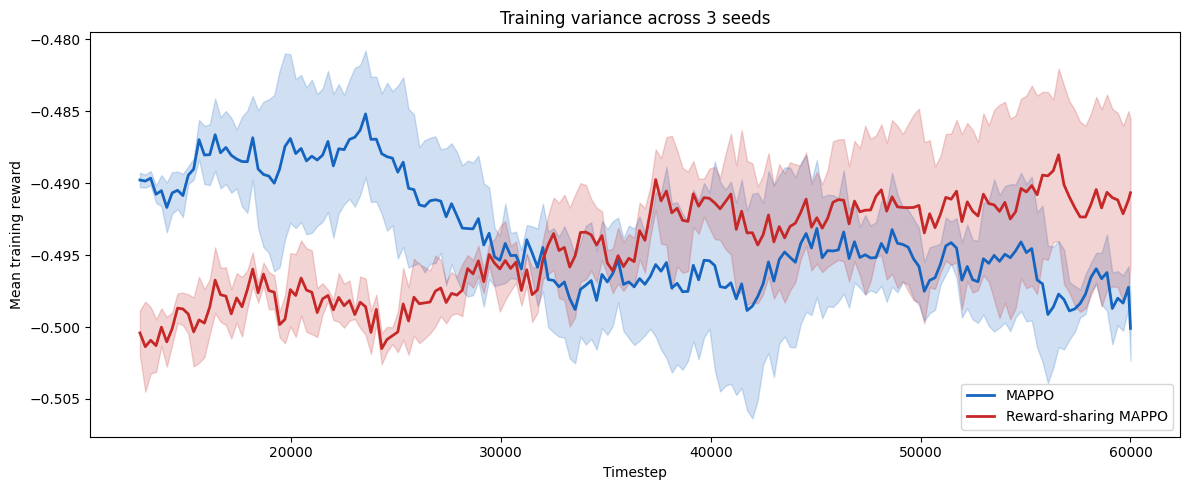

In [16]:
EXP_SWEEP = True
SEED_RANGE = 3
if EXP_SWEEP:
    from marl_tsc.exp_functions import save_history, plot_variance
    import torch

    histories_mappo = []
    histories_rs   = []
    evaluation_histories = []

    #Run experiment sweeps
    for seed in range(SEED_RANGE):
          torch.manual_seed(seed)
          print(f"|Seed: {seed} used for sweep|")

          #Run MAPPO
          mappo_model, mappo_history, mappo_path = train_mappo(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              output_dir=OUTPUT_DIR,
              total_timesteps=TOTAL_TIMESTEPS,
              rollout_steps=256,
              max_steps=EPISODE_STEPS,
              seed=seed,
              env_kwargs=ENV_KWARGS,
              use_peer_reward=False,
          )

          #Run reward sharing
          reward_sharing_model, reward_sharing_history, reward_sharing_path = train_mappo(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              output_dir=OUTPUT_DIR,
              total_timesteps=TOTAL_TIMESTEPS,
              rollout_steps=256,
              max_steps=EPISODE_STEPS,
              seed=seed,
              env_kwargs=ENV_KWARGS,
              use_peer_reward=True,
          )
          #Append and save
          histories_mappo.append(mappo_history)#accumulate in memory
          histories_rs.append(reward_sharing_history)
          save_history(mappo_history, seed, "mappo_4x4", OUTPUT_DIR)#save to as backup
          save_history(reward_sharing_history, seed, "rs_4x4", OUTPUT_DIR)

          #Display
          fig, ax = plot_training_histories({
          "MAPPO": mappo_history,
          "Reward-sharing MAPPO": reward_sharing_history,
          })
          plt.show()

          #Evaluate
          policies = {
          "Random": random_actions,
          "Fixed-Time": fixed_time_actions,
          "MAPPO": mappo_model,
          "Reward-sharing MAPPO": reward_sharing_model,
          }

          policy_results = evaluate_policies(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              policies=policies,
              episodes=EVALUATION_EPISODES,
              max_steps=EPISODE_STEPS,
              seed=SEED,
              env_kwargs=ENV_KWARGS,
          )
          evaluation_histories.append(policy_results)
          save_history(policy_results, seed, "eval", OUTPUT_DIR)

          display(evaluation_results_table(policy_results))

    fig, ax = plt.subplots(figsize=(12, 5))
    plot_variance(histories_mappo, "MAPPO",              "#1565C0", ax)
    plot_variance(histories_rs,   "Reward-sharing MAPPO", "#C62828", ax)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Mean training reward")
    ax.legend()
    ax.set_title(f"Training variance across {SEED_RANGE} seeds")
    plt.tight_layout()
    plt.show()

In [19]:
if EXP_SWEEP:
  import numpy as np
  metrics = ["mean_total_reward", "mean_local_queue", "mean_waiting_time",
            "mean_max_waiting_time", "mean_total_time_loss",
            "mean_arrived_vehicles_per_episode", "mean_switches_per_episode"]

  rows = []
  for policy_name in ["Random", "Fixed-Time", "MAPPO", "Reward-sharing MAPPO"]:
      row = {"Policy": policy_name}
      for metric in metrics:
          values = [e[policy_name][metric] for e in evaluation_histories]
          row[f"{metric}_mean"] = np.mean(values)
          row[f"{metric}_std"]  = np.std(values)
      rows.append(row)

  df = pd.DataFrame(rows)
  print(df.to_string())

                 Policy  mean_total_reward_mean  mean_total_reward_std  mean_local_queue_mean  mean_local_queue_std  mean_waiting_time_mean  mean_waiting_time_std  mean_max_waiting_time_mean  mean_max_waiting_time_std  mean_total_time_loss_mean  mean_total_time_loss_std  mean_arrived_vehicles_per_episode_mean  mean_arrived_vehicles_per_episode_std  mean_switches_per_episode_mean  mean_switches_per_episode_std
0                Random            -1283.075000               0.000000               0.504635              0.000000               20.895747               0.000000                  244.666667                   0.000000                1708.693571                  0.000000                              966.000000                               0.000000                      713.666667                       0.000000
1            Fixed-Time            -1025.693750               0.000000               0.410573              0.000000               15.345032               0.000000            

In [20]:
if EXP_SWEEP:
  # Extract metric across seeds for each policy
  def perform_statisical_tests(metric, evaluation_histories, test_type):
    from scipy import stats
    mappo_grouping = [e["MAPPO"][metric] for e in evaluation_histories]
    rs_grouping   = [e["Reward-sharing MAPPO"][metric] for e in evaluation_histories]

    # Paired t-test — paired because same seed = same traffic conditions
    if test_type == "paired_t":
      _stat, p_value = stats.ttest_rel(mappo_grouping, rs_grouping)
      print(f"t={_stat:.5f}, p={p_value:.4f}")
    elif test_type == 'wilk':
      _stat, p_value = stats.wilcoxon(mappo_grouping, rs_grouping)
      print(f"W={_stat:.5f}, p={p_value:.4f}")
    else:
      raise ValueError(f"Unknown test type: {test_type}")

    return _stat

  perform_statisical_tests("mean_local_queue", evaluation_histories, "wilk")

W=0.00000, p=0.2500


In [ ]:
!git status
#!git add .
commit = False
if commit:
  import shlex
  commit_msg = '''
  File for functions for use with seeded experiments added
  '''
  !git config --global user.email user_email
  !git config --global user.name 'IsaacFayle-Waters'
  !git commit -m {shlex.quote(commit_msg)}

In [ ]:
#!git remote set-url origin https://{token}@github.com/abergh18/marl-tsc.git
#!git push -u origin zak-pre-experiment